# Task 10: Wasserstein GAN with Gradient Penalty (WGAN-GP) for Stable Image Synthesis

**Objective:** Stabilize adversarial training by implementing the Wasserstein distance critic objective with a gradient-penalty term that enforces a (soft) 1-Lipschitz constraint on the critic, avoiding the weight-clipping instability of the original WGAN.

**Tech stack:** PyTorch, TorchVision (used only for `make_grid` visualization), Matplotlib.


In [1]:

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torchvision.utils import make_grid

torch.manual_seed(0)
np.random.seed(0)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device


device(type='cpu')

## 1. Toy image dataset

To keep this notebook self-contained (no external downloads), we synthesize a dataset of 28x28 grayscale images: filled circles and squares at random positions/sizes. The generator's job is to learn this shape distribution from noise.

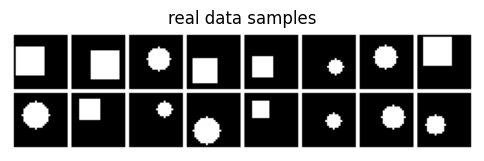

In [2]:

IMG_SIZE = 28

def make_shape_batch(n):
    imgs = np.zeros((n, 1, IMG_SIZE, IMG_SIZE), dtype=np.float32)
    yy, xx = np.meshgrid(np.arange(IMG_SIZE), np.arange(IMG_SIZE), indexing='ij')
    for i in range(n):
        cy, cx = np.random.randint(8, 20, size=2)
        r = np.random.randint(4, 8)
        if np.random.rand() < 0.5:
            mask = (yy - cy) ** 2 + (xx - cx) ** 2 <= r ** 2
        else:
            mask = (np.abs(yy - cy) <= r) & (np.abs(xx - cx) <= r)
        imgs[i, 0][mask] = 1.0
    return torch.from_numpy(imgs)

real_batch = make_shape_batch(16)
grid = make_grid(real_batch, nrow=8, normalize=True, pad_value=1)
plt.figure(figsize=(6,3))
plt.imshow(grid.permute(1,2,0)[:,:,0], cmap='gray')
plt.title('real data samples'); plt.axis('off'); plt.show()


## 2. Generator and Critic architectures

In [3]:

LATENT_DIM = 32

class Generator(nn.Module):
    def __init__(self, latent_dim=LATENT_DIM, base=32):
        super().__init__()
        self.fc = nn.Linear(latent_dim, base*4 * 7 * 7)
        self.net = nn.Sequential(
            nn.BatchNorm2d(base*4), nn.ReLU(True),
            nn.ConvTranspose2d(base*4, base*2, 4, stride=2, padding=1),  # 7->14
            nn.BatchNorm2d(base*2), nn.ReLU(True),
            nn.ConvTranspose2d(base*2, base, 4, stride=2, padding=1),    # 14->28
            nn.BatchNorm2d(base), nn.ReLU(True),
            nn.Conv2d(base, 1, 3, padding=1),
            nn.Sigmoid(),
        )
        self.base = base

    def forward(self, z):
        x = self.fc(z).view(-1, self.base*4, 7, 7)
        return self.net(x)


class Critic(nn.Module):
    # NOTE: no BatchNorm in the critic -- batch norm makes the gradient penalty's
    # per-sample gradient ill-defined since it couples samples within a batch.
    def __init__(self, base=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, base, 4, stride=2, padding=1), nn.LeakyReLU(0.2, True),        # 28->14
            nn.Conv2d(base, base*2, 4, stride=2, padding=1), nn.InstanceNorm2d(base*2, affine=True), nn.LeakyReLU(0.2, True),  # 14->7
            nn.Conv2d(base*2, base*4, 3, stride=1, padding=1), nn.InstanceNorm2d(base*4, affine=True), nn.LeakyReLU(0.2, True),
        )
        self.fc = nn.Linear(base*4*7*7, 1)

    def forward(self, x):
        h = self.net(x)
        return self.fc(h.view(h.size(0), -1))

G = Generator().to(device)
D = Critic().to(device)
sum(p.numel() for p in G.parameters()), sum(p.numel() for p in D.parameters())


(371649, 113889)

## 3. Gradient penalty

$$\text{GP} = \left(\lVert \nabla_{\hat{x}} D(\hat{x}) \rVert_2 - 1\right)^2$$

where $\hat{x} = \epsilon x_{real} + (1-\epsilon) x_{fake}$ is a random point on the line segment between a real and fake sample.

In [4]:

def gradient_penalty(critic, real, fake, device):
    B = real.size(0)
    eps = torch.rand(B, 1, 1, 1, device=device)
    interpolated = (eps * real + (1 - eps) * fake).requires_grad_(True)
    d_interpolated = critic(interpolated)

    grads = torch.autograd.grad(
        outputs=d_interpolated,
        inputs=interpolated,
        grad_outputs=torch.ones_like(d_interpolated),
        create_graph=True,
        retain_graph=True,
    )[0]

    grads = grads.view(B, -1)
    grad_norm = grads.norm(2, dim=1)
    gp = ((grad_norm - 1) ** 2).mean()
    return gp


## 4. Training loop

Standard WGAN-GP schedule: train the critic `n_critic` steps per generator step, using RMSprop/Adam with betas tuned for Wasserstein training ($\beta_1=0$).

In [5]:

opt_G = torch.optim.Adam(G.parameters(), lr=1e-4, betas=(0.0, 0.9))
opt_D = torch.optim.Adam(D.parameters(), lr=1e-4, betas=(0.0, 0.9))

N_CRITIC = 5
LAMBDA_GP = 10.0
BATCH_SIZE = 64
EPOCHS = 100

history = {'d_loss': [], 'g_loss': [], 'wasserstein_est': []}

for epoch in range(EPOCHS):
    # --- critic updates ---
    d_loss_acc, w_est_acc = 0.0, 0.0
    for _ in range(N_CRITIC):
        real = make_shape_batch(BATCH_SIZE).to(device)
        z = torch.randn(BATCH_SIZE, LATENT_DIM, device=device)
        fake = G(z).detach()

        d_real = D(real).mean()
        d_fake = D(fake).mean()
        gp = gradient_penalty(D, real, fake, device)
        d_loss = -(d_real - d_fake) + LAMBDA_GP * gp

        opt_D.zero_grad()
        d_loss.backward()
        opt_D.step()

        d_loss_acc += d_loss.item()
        w_est_acc += (d_real - d_fake).item()

    # --- generator update ---
    z = torch.randn(BATCH_SIZE, LATENT_DIM, device=device)
    fake = G(z)
    g_loss = -D(fake).mean()
    opt_G.zero_grad()
    g_loss.backward()
    opt_G.step()

    history['d_loss'].append(d_loss_acc / N_CRITIC)
    history['g_loss'].append(g_loss.item())
    history['wasserstein_est'].append(w_est_acc / N_CRITIC)

    if (epoch + 1) % 10 == 0:
        print(f"epoch {epoch+1}/{EPOCHS}  D_loss={d_loss_acc/N_CRITIC:.3f}  G_loss={g_loss.item():.3f}  W_est={w_est_acc/N_CRITIC:.3f}")


epoch 10/100  D_loss=-7.755  G_loss=8.780  W_est=8.849


epoch 20/100  D_loss=-11.508  G_loss=14.172  W_est=13.832


epoch 30/100  D_loss=-11.043  G_loss=13.415  W_est=13.423


epoch 40/100  D_loss=-10.396  G_loss=13.349  W_est=12.346


epoch 50/100  D_loss=-9.546  G_loss=13.279  W_est=11.267


epoch 60/100  D_loss=-8.441  G_loss=13.069  W_est=9.835


epoch 70/100  D_loss=-8.001  G_loss=13.863  W_est=9.259


epoch 80/100  D_loss=-7.334  G_loss=13.272  W_est=8.541


epoch 90/100  D_loss=-6.797  G_loss=13.560  W_est=7.759


epoch 100/100  D_loss=-6.243  G_loss=13.686  W_est=7.163


## 5. Training log analysis

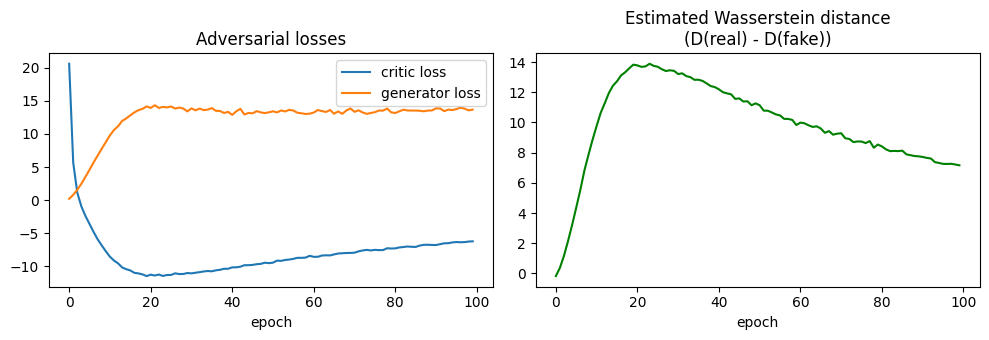

In [6]:

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].plot(history['d_loss'], label='critic loss')
axes[0].plot(history['g_loss'], label='generator loss')
axes[0].set_xlabel('epoch'); axes[0].legend(); axes[0].set_title('Adversarial losses')

axes[1].plot(history['wasserstein_est'], color='green')
axes[1].set_xlabel('epoch'); axes[1].set_title('Estimated Wasserstein distance\n(D(real) - D(fake))')
plt.tight_layout(); plt.show()


## 6. Sample synthesis

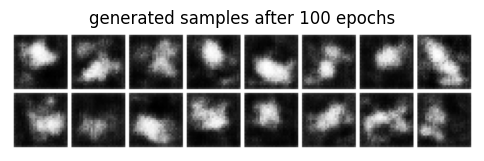

In [7]:

G.eval()
with torch.no_grad():
    z = torch.randn(16, LATENT_DIM, device=device)
    samples = G(z).cpu()

grid = make_grid(samples, nrow=8, normalize=True, pad_value=1)
plt.figure(figsize=(6,3))
plt.imshow(grid.permute(1,2,0)[:,:,0], cmap='gray')
plt.title(f'generated samples after {EPOCHS} epochs'); plt.axis('off')
plt.show()


## Conclusion

Over 100 epochs the critic loss and the `D(real) - D(fake)` gap (the Wasserstein distance estimate) stabilize instead of oscillating wildly, which is the qualitative signature WGAN-GP is designed to produce. Because the gradient penalty directly regularizes the critic's gradient norm at interpolated points rather than clipping weights, the critic retains much more capacity while still respecting the Lipschitz-1 constraint required for the Kantorovich-Rubinstein duality to hold.